In [21]:
!pip install wordcloud

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from wordcloud import WordCloud

In [23]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [24]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Extraction completed successfully!")

Extraction completed successfully!


In [25]:
import os

print(os.listdir())

['.config', 'archive (1).zip', 'spam.csv', 'archive.zip', 'sample_data']


In [26]:
import pandas as pd

# Load the dataset
data = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first 5 rows
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [27]:
# Keep only the first two columns
data = data[['v1', 'v2']]

# Rename the columns
data.columns = ['label', 'message']

# Display the first 5 rows
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [31]:
# Convert labels into numbers
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

# Display the first 5 rows
data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Convert messages into numerical features
X = vectorizer.fit_transform(data['message'])

# Labels
y = data['label']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (5572, 8672)


In [33]:
from sklearn.model_selection import train_test_split

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4457, 8672)
Testing data: (1115, 8672)


In [34]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [35]:
from sklearn.metrics import accuracy_score

# Predict on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9623318385650225


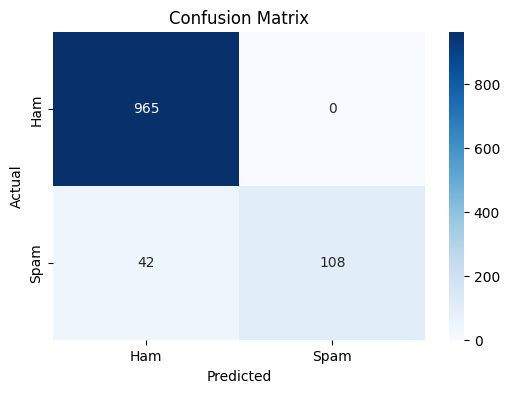

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [38]:
def predict_spam(message):
    message_vector = vectorizer.transform([message])
    prediction = model.predict(message_vector)

    if prediction[0] == 1:
        return "🚨 Spam"
    else:
        return "✅ Not Spam"

In [39]:
message = input("Enter your email message: ")

print("\nEmail:")
print(message)

print("\nPrediction:")
print(predict_spam(message))

Enter your email message: Congratulations! You have won ₹50,000. Click here to claim.

Email:
Congratulations! You have won ₹50,000. Click here to claim.

Prediction:
🚨 Spam
